<a href="https://colab.research.google.com/github/silvanalorens/MCC225/blob/main/ExperimentoXCLIPvsOpenCLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Fase 2 Proyecto de XCLIP

Primero reutilizamos lo obtenido de Fase 1
El archivo `activitynet_subset.csv` contiene los segmentos de video seleccionados. Cada fila define un intervalo temporal y su descripción asociada.

Por ejemplo:

| video_id      | segment_id | start | end  | caption                                                      |
| ------------- | ---------- | ----- | ---- | ------------------------------------------------------------ |
| v_bQ3yPbCICRg | 0          | 0.00  | 2.31 | A man is seen bending over a bang in the middle of drummers. |

Para este segmento, X-CLIP realiza el siguiente proceso:

```text
Video: bQ3yPbCICRg.mp4
Intervalo: [0.00s , 2.31s]
        │
        ▼
Extraer 8 frames
uniformemente
        │
        ▼
Frame 1
Frame 2
...
Frame 8
        │
        ▼
X-CLIP Video Encoder
        │
        ▼
Video Embedding
(512 dimensiones)
```

El embedding obtenido representa el contenido visual completo del segmento comprendido entre los segundos 0.00 y 2.31 del video.

Este procedimiento se repite para todos los segmentos presentes en `activitynet_subset.csv`, generando finalmente el archivo:

```text
segment_embeddings.npy
```

que contiene una representación vectorial para cada segmento de video.
Shape: (109, 512)

Primer embedding:
[ 0.04707476  0.0796271  -0.04736551 -0.01435806 -0.00423853  0.01133263
  0.02164728 -0.04505922 -0.10145714 -0.00206986 -0.00116935  0.04275819
  0.02357092  0.01472777 -0.0130752  -0.02067476 -0.03003927  0.03859328
 -0.03202799  0.01091633]


In [ ]:
#Código para ver el vector de ejemplo
import numpy as np

embeddings = np.load(
    "/content/drive/MyDrive/xclip_project/outputs/embeddings/segment_embeddings.npy"
)

print("Shape:", embeddings.shape)

print("\nPrimer embedding:")
print(embeddings[0][:20])  # primeras 20 dimensiones

### Generación de Embeddings con X-CLIP

La construcción de los embeddings se divide en dos etapas: una para los segmentos de video y otra para las descripciones textuales.

#### 1. Embeddings de Video (`08_build_xclip_embeddings.py`)

Este script utiliza como entrada el archivo `activitynet_subset.csv`, generado en la fase anterior. Para cada segmento definido por los tiempos de inicio (`start`) y fin (`end`), se extraen 8 frames distribuidos uniformemente dentro del intervalo temporal.

Los frames son procesados mediante el modelo preentrenado **X-CLIP (`microsoft/xclip-base-patch32`)**, obteniendo un embedding que representa el contenido visual completo del segmento.

```text
activitynet_subset.csv
        │
        ▼
Segmento de Video
(start, end)
        │
        ▼
Extraer 8 Frames
        │
        ▼
X-CLIP Video Encoder
        │
        ▼
Video Embedding
        │
        ▼
L2 Normalization
        │
        ▼
segment_embeddings.npy
```

Archivos generados:

```text
outputs/embeddings/
├── segment_embeddings.npy
└── segment_metadata.csv
```

#### 2. Embeddings de Texto (`09_build_text_embeddings.py`)

Este script utiliza las captions almacenadas en `activitynet_subset.csv`. Cada descripción es procesada por el encoder de texto de X-CLIP para obtener una representación vectorial en el mismo espacio multimodal que los videos.

```text
Caption
        │
        ▼
X-CLIP Text Encoder
        │
        ▼
Text Embedding
        │
        ▼
L2 Normalization
        │
        ▼
text_embeddings.npy
```

Archivos generados:

```text
outputs/embeddings/
├── text_embeddings.npy
└── text_metadata.csv
```

#### Relación entre ambos embeddings

Los embeddings de video y texto son generados en el mismo espacio latente. Posteriormente, se calcula la similitud coseno entre ambos para recuperar los segmentos de video más relevantes para cada consulta textual.

```text
Video Segment
        │
        ▼
segment_embeddings.npy
        │
        ├───────────────┐
        ▼               ▼
Cosine Similarity  text_embeddings.npy
        ▲
        │
Caption
```

Estos embeddings serán utilizados en la etapa de evaluación para calcular las métricas Recall@1, Recall@5, Recall@10 y Mean Reciprocal Rank (MRR).


In [ ]:
# ============================================================
# 08_build_xclip_embeddings.py
#
# Genera embeddings de video usando:
# microsoft/xclip-base-patch32
#
# Dataset:
# activitynet_subset.csv
#
# Salidas:
# outputs/embeddings/
#   segment_embeddings.npy
#   segment_metadata.csv
#   progress.txt
#
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from tqdm import tqdm
from transformers import AutoProcessor, AutoModel

# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/xclip_project"

CSV_PATH = f"{BASE_DIR}/data/activitynet/activitynet_subset.csv"

VIDEO_DIR = f"{BASE_DIR}/data/activitynet/videos"

OUTPUT_DIR = f"{BASE_DIR}/outputs/embeddings"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# FILES
# ============================================================

EMBEDDINGS_FILE = f"{OUTPUT_DIR}/segment_embeddings.npy"

METADATA_FILE = f"{OUTPUT_DIR}/segment_metadata.csv"

PARTIAL_EMBEDDINGS_FILE = (
    f"{OUTPUT_DIR}/segment_embeddings_partial.npy"
)

PARTIAL_METADATA_FILE = (
    f"{OUTPUT_DIR}/segment_metadata_partial.csv"
)

PROGRESS_FILE = (
    f"{OUTPUT_DIR}/progress.txt"
)

# ============================================================
# CONFIG
# ============================================================

NUM_FRAMES = 8

SAVE_EVERY = 10

MODEL_NAME = "microsoft/xclip-base-patch32"

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

# ============================================================
# MODEL
# ============================================================

print("Loading XCLIP...")

processor = AutoProcessor.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
).to(DEVICE)

model.eval()

print("Model loaded.")

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))

# ============================================================
# RESUME SUPPORT
# ============================================================

start_idx = 0

all_embeddings = []
metadata_rows = []

if os.path.exists(PROGRESS_FILE):

    with open(PROGRESS_FILE, "r") as f:
        start_idx = int(f.read().strip())

    print(
        f"Resuming from row {start_idx}"
    )

    if os.path.exists(PARTIAL_EMBEDDINGS_FILE):

        all_embeddings = list(
            np.load(
                PARTIAL_EMBEDDINGS_FILE
            )
        )

    if os.path.exists(PARTIAL_METADATA_FILE):

        metadata_rows = (
            pd.read_csv(
                PARTIAL_METADATA_FILE
            )
            .to_dict("records")
        )

else:

    print("Starting from scratch.")

# ============================================================
# FRAME EXTRACTION
# ============================================================

def sample_segment_frames(
    video_path,
    start_time,
    end_time,
    num_frames=8
):
    """
    Extrae exactamente num_frames frames.

    """

    cap = cv2.VideoCapture(str(video_path))

    timestamps = np.linspace(
        start_time,
        end_time,
        num_frames
    )

    frames = []

    for t in timestamps:

        cap.set(
            cv2.CAP_PROP_POS_MSEC,
            t * 1000
        )

        ok, frame = cap.read()

        if ok:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frames.append(frame)

    cap.release()

    # si no obtuvo ningún frame
    if len(frames) == 0:
        return None

    # completar hasta tener exactamente 8
    while len(frames) < num_frames:

        frames.append(
            frames[-1].copy()
        )

    # por seguridad
    frames = frames[:num_frames]

    return frames
# ============================================================
# MAIN LOOP
# ============================================================

for idx in tqdm(
    range(start_idx, len(df))
    #range(0,10)
):

    row = df.iloc[idx]

    video_path = os.path.join(
        VIDEO_DIR,
        row["video_file"]
    )

    if not os.path.exists(video_path):

        print(
            f"Missing video: {video_path}"
        )
        continue

    frames = sample_segment_frames(
        video_path,
        row["start"],
        row["end"],
        NUM_FRAMES
    )

    if frames is None:

        print(
            f"Failed frame extraction: {video_path}"
        )
        continue

    try:

        inputs = processor(
            images=frames,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(DEVICE)
            for k, v in inputs.items()
        }

        with torch.no_grad():

            outputs = model.get_video_features(
                pixel_values=inputs["pixel_values"]
            )

        # Compatible con distintas versiones
        if hasattr(outputs, "pooler_output"):
            embedding = outputs.pooler_output
        else:
            embedding = outputs

        embedding = torch.nn.functional.normalize(
            embedding,
            p=2,
            dim=-1
        )

        embedding = (
            embedding
            .cpu()
            .numpy()
        )

        all_embeddings.append(
            embedding
        )

        metadata_rows.append({
            "video_id":
                row["video_id"],

            "youtube_id":
                row["youtube_id"],

            "video_file":
                row["video_file"],

            "segment_id":
                row["segment_id"],

            "start":
                row["start"],

            "end":
                row["end"],

            "caption":
                row["caption"]
        })

    except Exception as e:

        print(
            f"Error row {idx}: {e}"
        )

        continue

    # ========================================================
    # CHECKPOINT
    # ========================================================

    processed = len(
        all_embeddings
    )

    if (
        processed > 0
        and
        processed % SAVE_EVERY == 0
    ):

        np.save(
            PARTIAL_EMBEDDINGS_FILE,
            np.vstack(
                all_embeddings
            )
        )

        pd.DataFrame(
            metadata_rows
        ).to_csv(
            PARTIAL_METADATA_FILE,
            index=False
        )

        with open(
            PROGRESS_FILE,
            "w"
        ) as f:

            f.write(
                str(idx + 1)
            )

        print(
            f"Checkpoint saved "
            f"({processed} segments)"
        )

# ============================================================
# FINAL SAVE
# ============================================================

print("Saving final files...")

embeddings = np.vstack(
    all_embeddings
)

metadata = pd.DataFrame(
    metadata_rows
)

np.save(
    EMBEDDINGS_FILE,
    embeddings
)

metadata.to_csv(
    METADATA_FILE,
    index=False
)

with open(
    PROGRESS_FILE,
    "w"
) as f:

    f.write(
        str(len(df))
    )

print()
print("Done.")
print(
    "Embeddings shape:",
    embeddings.shape
)
print(
    "Saved:",
    EMBEDDINGS_FILE
)
print(
    "Saved:",
    METADATA_FILE
)

In [ ]:
# ============================================================
# 09_build_text_embeddings.py
#
# Genera embeddings de texto usando X-CLIP
#
# Salidas:
#   text_embeddings.npy
#   text_metadata.csv
#
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from tqdm import tqdm
from transformers import AutoProcessor, AutoModel

# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/xclip_project"

CSV_PATH = (
    f"{BASE_DIR}/data/activitynet/activitynet_subset.csv"
)

OUTPUT_DIR = (
    f"{BASE_DIR}/outputs/embeddings"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

TEXT_EMBEDDINGS_FILE = (
    f"{OUTPUT_DIR}/text_embeddings.npy"
)

TEXT_METADATA_FILE = (
    f"{OUTPUT_DIR}/text_metadata.csv"
)

# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = (
    "microsoft/xclip-base-patch32"
)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

# ============================================================
# MODEL
# ============================================================

print("Loading XCLIP...")

processor = AutoProcessor.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME
).to(DEVICE)

model.eval()

print("Model loaded.")

# ============================================================
# DATA
# ============================================================

df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))

# ============================================================
# BUILD TEXT EMBEDDINGS
# ============================================================

all_embeddings = []

for caption in tqdm(df["caption"]):

    inputs = processor(
        text=[str(caption)],
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model.get_text_features(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

    if hasattr(outputs, "pooler_output"):
        embedding = outputs.pooler_output
    else:
        embedding = outputs

    embedding = torch.nn.functional.normalize(
        embedding,
        p=2,
        dim=-1
    )

    embedding = embedding.squeeze(0)

    embedding = embedding.cpu().numpy()

    all_embeddings.append(
        embedding
    )

# ============================================================
# SAVE
# ============================================================

embeddings = np.vstack(
    all_embeddings
)

np.save(
    TEXT_EMBEDDINGS_FILE,
    embeddings
)

df.to_csv(
    TEXT_METADATA_FILE,
    index=False
)

print()
print("Done.")
print(
    "Embeddings shape:",
    embeddings.shape
)

print(
    "Saved:",
    TEXT_EMBEDDINGS_FILE
)

### Recuperación Texto-a-Video (`10_text_to_video_retrieval.py`)

Una vez generados los embeddings de video y texto con X-CLIP, se realiza una búsqueda de segmentos de video a partir de una consulta textual.

El script carga los embeddings almacenados en `segment_embeddings.npy` y `text_embeddings.npy`, junto con la información de los segmentos contenida en `segment_metadata.csv`.

Se selecciona una caption como consulta (`query_caption`) y se obtiene su embedding correspondiente.

Posteriormente, se calcula la similitud entre el embedding de la consulta y todos los embeddings de video mediante el producto punto. Como los embeddings fueron previamente normalizados, esta operación equivale a calcular la similitud coseno.

Los segmentos son ordenados de mayor a menor similitud y se recuperan los **Top-K** resultados más relevantes.

#### Pipeline

```text
Query Caption
        │
        ▼
Text Embedding
        │
        ▼
Cosine Similarity
        │
        ├─────────────────► Video Embedding 1
        ├─────────────────► Video Embedding 2
        ├─────────────────► Video Embedding 3
        └─────────────────► ...
        │
        ▼
Ranking de Similitud
        │
        ▼
Top-K Videos
```

#### Archivos utilizados

```text
outputs/embeddings/
├── segment_embeddings.npy
├── text_embeddings.npy
└── segment_metadata.csv
```

#### Salida

Para cada resultado recuperado se muestran:

* Posición en el ranking.
* Puntaje de similitud.
* Nombre del video.
* Caption asociada al segmento.

```text
Rank 1
Score: 0.8231
Video: example.mp4
Caption: ...
```

Este procedimiento permite verificar cualitativamente la capacidad de X-CLIP para recuperar los segmentos de video más relevantes a partir de una descripción en lenguaje natural.


### Resultados de Recuperación

La evaluación se realizó sobre un subconjunto de **109 segmentos** de ActivityNet. Se consideraron dos tareas de recuperación:

* **Text → Video:** recuperar el segmento de video correcto a partir de una descripción textual.
* **Video → Text:** recuperar la descripción correcta a partir de un segmento de video.

#### Resultados

| Métrica   | Text → Video | Video → Text |
| --------- | -----------: | -----------: |
| Recall@1  |        0.138 |        0.239 |
| Recall@5  |        0.394 |        0.642 |
| Recall@10 |        0.541 |        0.725 |

#### Interpretación

Los resultados muestran que la tarea **Video → Text** obtuvo un mejor desempeño que **Text → Video** en todos los niveles de recuperación.

En la tarea Text → Video, el segmento correcto fue recuperado en la primera posición para aproximadamente el 13.8% de las consultas y dentro de los diez primeros resultados para el 54.1% de los casos.

Por otro lado, en la tarea Video → Text, la descripción correcta apareció en la primera posición para aproximadamente el 23.9% de los segmentos y dentro de los diez primeros resultados para el 72.5% de los casos.

Estos resultados indican que los embeddings generados por X-CLIP capturan adecuadamente la relación entre videos y texto, aunque la recuperación exacta en la primera posición continúa siendo un desafío debido a la similitud semántica existente entre múltiples segmentos del conjunto de datos.


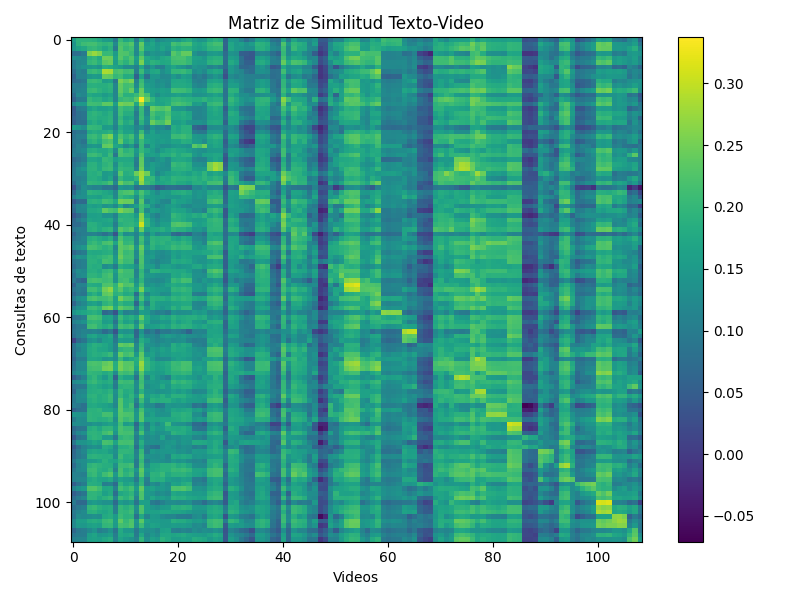

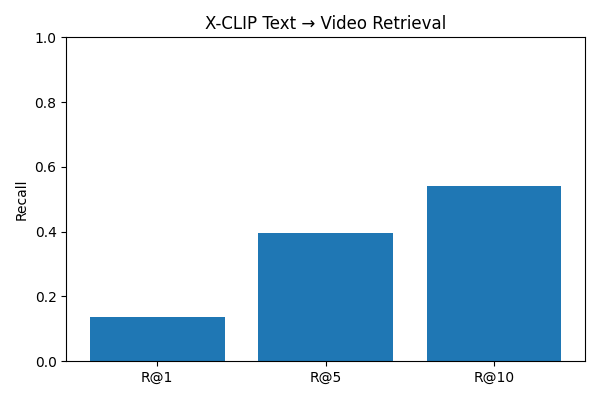

### Comparación de Resultados: OpenCLIP vs X-CLIP

Se evaluaron ambos modelos sobre el mismo subconjunto de ActivityNet utilizando métricas de recuperación. OpenCLIP empleó 5 frames por segmento con agregación mediante mean pooling, mientras que X-CLIP utilizó 8 frames e incorporó modelado temporal en la representación de video.

#### Resultados

| Métrica   | OpenCLIP | X-CLIP (Text→Video) |
| --------- | -------: | ------------------: |
| Recall@1  |    0.229 |               0.138 |
| Recall@5  |    0.716 |               0.394 |
| Recall@10 |    0.817 |               0.541 |

#### Análisis

En este experimento, OpenCLIP obtuvo mejores resultados que X-CLIP en la tarea de recuperación texto-a-video.

OpenCLIP logró recuperar el segmento correcto en la primera posición para aproximadamente el 22.9% de las consultas, mientras que X-CLIP alcanzó un 13.8%. La diferencia también se mantiene en Recall@5 y Recall@10.

Una posible explicación es el tamaño reducido del subconjunto utilizado (109 segmentos), donde una estrategia simple basada en embeddings de frames individuales y mean pooling puede resultar suficiente para capturar la información relevante.

Además, OpenCLIP fue utilizado como una línea base eficiente basada en imágenes, mientras que X-CLIP está diseñado para explotar relaciones temporales entre frames. Las ventajas de este modelado temporal suelen apreciarse con mayor claridad en conjuntos de datos más grandes o en tareas donde la dinámica temporal es fundamental para distinguir entre acciones similares.

#### Conclusión

Aunque X-CLIP incorpora mecanismos específicos para comprensión de video, los resultados obtenidos en este experimento muestran que OpenCLIP alcanzó un mejor desempeño de recuperación texto-a-video sobre el subconjunto evaluado de ActivityNet. Esto sugiere que, para este escenario particular, la información visual estática capturada por los frames seleccionados fue suficiente para representar adecuadamente los segmentos de video.

#### Limitaciones de la Evaluación

Una limitación importante del conjunto de datos es que varios segmentos pertenecen al mismo video y describen acciones muy similares en intervalos temporales consecutivos.

Como consecuencia, una consulta textual puede corresponder semánticamente a más de un segmento candidato. Aunque el modelo recupere un segmento visualmente relevante, este puede no coincidir exactamente con el segmento considerado como correcto durante la evaluación.

Por ejemplo, acciones continuas como correr, tocar un instrumento o cocinar suelen extenderse durante varios segundos y pueden aparecer descritas mediante captions muy parecidas en distintos segmentos del mismo video.

Esta característica puede reducir las métricas de recuperación, especialmente Recall@1, aun cuando los resultados recuperados sean razonablemente correctos desde el punto de vista semántico.



### Recuperación Bidireccional con X-CLIP

A diferencia de OpenCLIP, en X-CLIP se evaluaron dos tareas de recuperación multimodal:

* **Text → Video:** recuperar el segmento de video correcto a partir de una descripción textual.
* **Video → Text:** recuperar la descripción correcta a partir de un segmento de video.

#### Resultados

| Métrica   | Text → Video | Video → Text |
| --------- | -----------: | -----------: |
| Recall@1  |        0.138 |        0.239 |
| Recall@5  |        0.394 |        0.642 |
| Recall@10 |        0.541 |        0.725 |

#### Análisis

Los resultados muestran una diferencia entre ambas tareas de recuperación. La tarea **Video → Text** obtuvo mejores métricas que **Text → Video** en todos los niveles de evaluación.

En particular, Video → Text alcanzó un Recall@10 de 72.5%, mientras que Text → Video obtuvo un Recall@10 de 54.1%.

Esto sugiere que los embeddings de video generados por X-CLIP contienen suficiente información semántica para identificar correctamente las descripciones asociadas. Sin embargo, una misma descripción textual puede ser compatible con varios segmentos visualmente similares, lo que dificulta la recuperación exacta del video correcto.

Estos resultados evidencian la capacidad bidireccional de X-CLIP para relacionar contenido visual y textual dentro de un espacio multimodal compartido.
